

===== FOLD 1 =====
Epoch 1/20 - Loss: 0.5769
Epoch 2/20 - Loss: 0.5118
Epoch 3/20 - Loss: 0.4810
Epoch 4/20 - Loss: 0.4668
Epoch 5/20 - Loss: 0.4591
Epoch 6/20 - Loss: 0.4630
Epoch 7/20 - Loss: 0.4586
Epoch 8/20 - Loss: 0.4428
Epoch 9/20 - Loss: 0.4633
Epoch 10/20 - Loss: 0.4661
Epoch 11/20 - Loss: 0.4749
Epoch 12/20 - Loss: 0.4574
Epoch 13/20 - Loss: 0.4596
Epoch 14/20 - Loss: 0.4403
Epoch 15/20 - Loss: 0.4447
Epoch 16/20 - Loss: 0.4338
Epoch 17/20 - Loss: 0.4323
Epoch 18/20 - Loss: 0.4363
Epoch 19/20 - Loss: 0.4607
Epoch 20/20 - Loss: 0.4483

Curva KS (CDF) para o Fold 1:


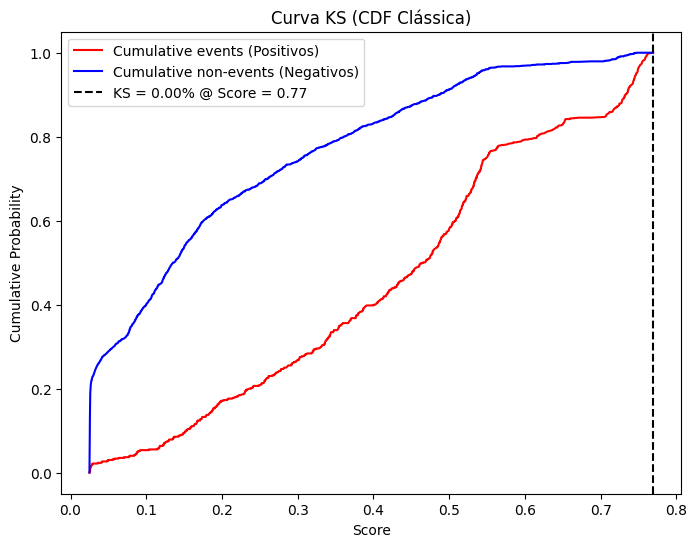

KS = 0.00% at Score = 0.7692


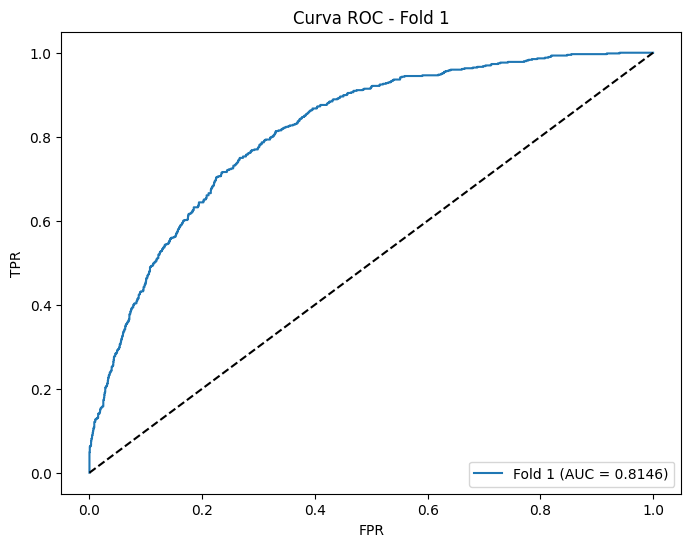

Fold 1 - Test Metrics:
  AUC      : 0.8146
  KS (CDF) : 0.00%  (Score: 0.7692)
  Accuracy : 0.7877
  Precision: 0.6203
  Recall   : 0.4202


===== FOLD 2 =====
Epoch 1/20 - Loss: 0.5979
Epoch 2/20 - Loss: 0.5620
Epoch 3/20 - Loss: 0.5064
Epoch 4/20 - Loss: 0.4970
Epoch 5/20 - Loss: 0.4896
Epoch 6/20 - Loss: 0.4959
Epoch 7/20 - Loss: 0.4906
Epoch 8/20 - Loss: 0.5144
Epoch 9/20 - Loss: 0.4860
Epoch 10/20 - Loss: 0.4885
Epoch 11/20 - Loss: 0.4933
Epoch 12/20 - Loss: 0.4929
Epoch 13/20 - Loss: 0.4810
Epoch 14/20 - Loss: 0.4908
Epoch 15/20 - Loss: 0.4742
Epoch 16/20 - Loss: 0.4890
Epoch 17/20 - Loss: 0.4740
Epoch 18/20 - Loss: 0.4632
Epoch 19/20 - Loss: 0.4804
Epoch 20/20 - Loss: 0.4837

Curva KS (CDF) para o Fold 2:


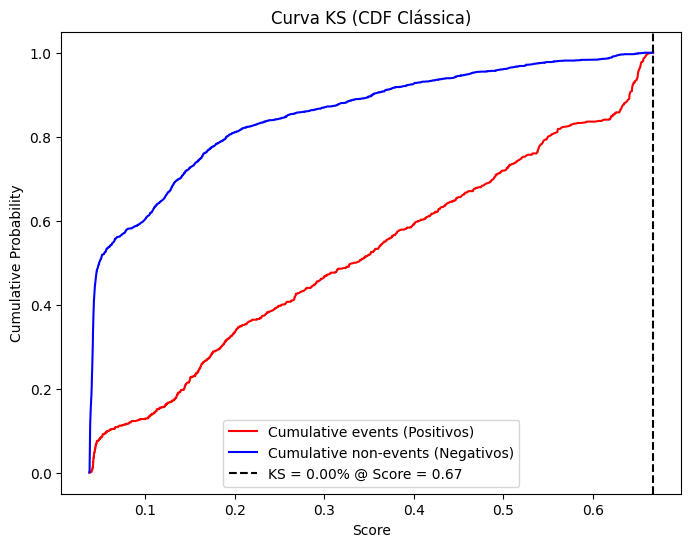

KS = 0.00% at Score = 0.6676


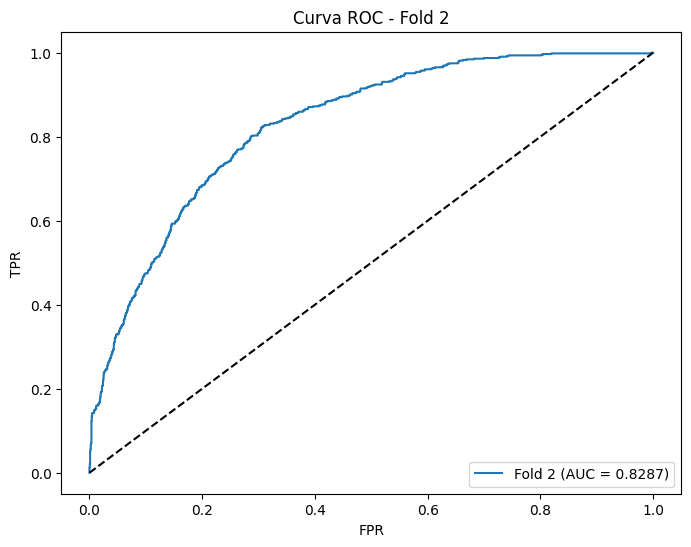

Fold 2 - Test Metrics:
  AUC      : 0.8287
  KS (CDF) : 0.00%  (Score: 0.6676)
  Accuracy : 0.7766
  Precision: 0.7236
  Recall   : 0.2808


===== FOLD 3 =====
Epoch 1/20 - Loss: 0.5824
Epoch 2/20 - Loss: 0.5664
Epoch 3/20 - Loss: 0.5426
Epoch 4/20 - Loss: 0.5019
Epoch 5/20 - Loss: 0.4999
Epoch 6/20 - Loss: 0.4841
Epoch 7/20 - Loss: 0.4699
Epoch 8/20 - Loss: 0.5066
Epoch 9/20 - Loss: 0.5038
Epoch 10/20 - Loss: 0.4848
Epoch 11/20 - Loss: 0.4707
Epoch 12/20 - Loss: 0.4766
Epoch 13/20 - Loss: 0.4887
Epoch 14/20 - Loss: 0.4906
Epoch 15/20 - Loss: 0.4918
Epoch 16/20 - Loss: 0.4810
Epoch 17/20 - Loss: 0.4835
Epoch 18/20 - Loss: 0.4706
Epoch 19/20 - Loss: 0.4726
Epoch 20/20 - Loss: 0.4561

Curva KS (CDF) para o Fold 3:


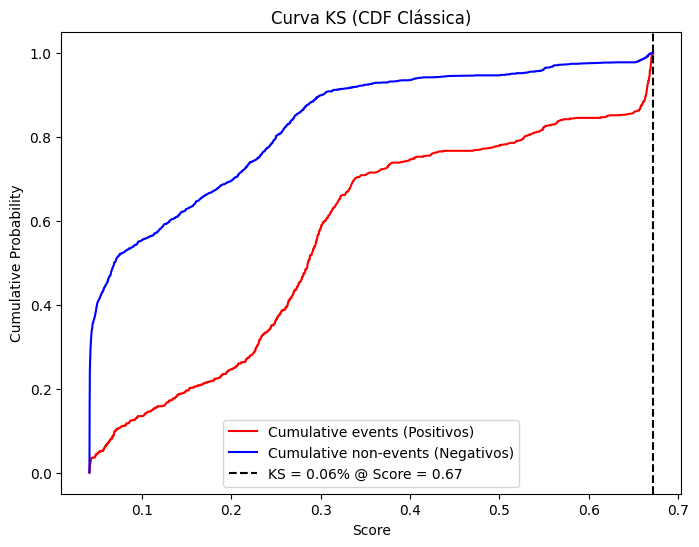

KS = 0.06% at Score = 0.6719


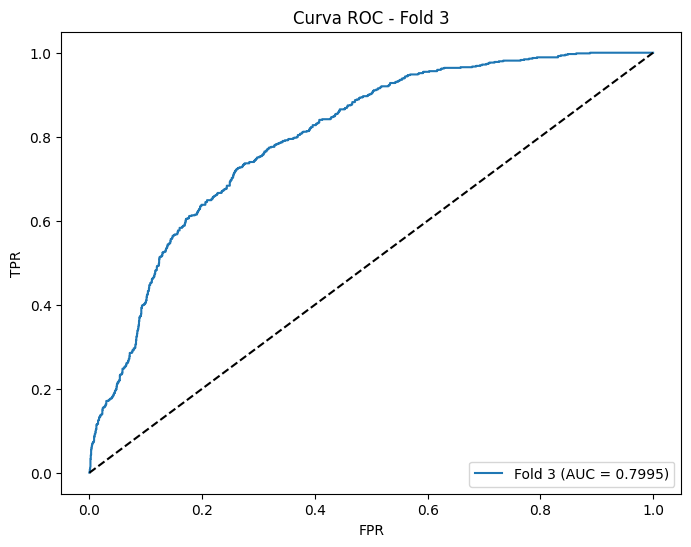

Fold 3 - Test Metrics:
  AUC      : 0.7995
  KS (CDF) : 0.06%  (Score: 0.6719)
  Accuracy : 0.7488
  Precision: 0.6052
  Recall   : 0.2210

===== RESULTADOS MÉDIOS GERAIS =====
AUC      : 0.8143 ± 0.0119
KS (CDF) : 0.02% ± 0.03%
Accuracy : 0.7711 ± 0.0164
Precision: 0.6497 ± 0.0526
Recall   : 0.3073 ± 0.0834


In [13]:
# -*- coding: utf-8 -*-
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_curve, auc, accuracy_score, precision_score, recall_score
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)

# -----------------------
# Função para plotar a curva KS (CDF Clássica)
# -----------------------
def plot_ks_cdf(y_true, y_pred):
    """
    Plota a curva KS (CDF) clássica:
      - curva cumulativa dos eventos (positivos)
      - curva cumulativa dos não-eventos (negativos)
    Também exibe uma linha vertical indicando o score onde ocorre o KS máximo.
    Retorna o valor do KS e o score associado.
    """
    # Ordena os scores e os rótulos de acordo com os scores
    sorted_indices = np.argsort(y_pred)
    sorted_scores = y_pred[sorted_indices]
    sorted_labels = y_true[sorted_indices]
    
    # Número de positivos e negativos
    n_pos = np.sum(sorted_labels == 1)
    n_neg = np.sum(sorted_labels == 0)
    
    # Calcula a função de distribuição acumulada para positivos e negativos
    cdf_pos = np.cumsum(sorted_labels) / n_pos
    cdf_neg = np.cumsum(1 - sorted_labels) / n_neg
    
    # KS: diferença máxima entre as CDFs
    ks_values = cdf_pos - cdf_neg
    max_ks = np.max(ks_values)
    max_ks_idx = np.argmax(ks_values)
    max_ks_score = sorted_scores[max_ks_idx]
    
    # Plot
    plt.figure(figsize=(8, 6))
    plt.plot(sorted_scores, cdf_pos, 'r', label='Cumulative events (Positivos)')
    plt.plot(sorted_scores, cdf_neg, 'b', label='Cumulative non-events (Negativos)')
    plt.axvline(x=max_ks_score, color='k', linestyle='--',
                label=f'KS = {max_ks*100:.2f}% @ Score = {max_ks_score:.2f}')
    plt.xlabel('Score')
    plt.ylabel('Cumulative Probability')
    plt.title('Curva KS (CDF Clássica)')
    plt.legend()
    plt.show()

    print(f"KS = {max_ks*100:.2f}% at Score = {max_ks_score:.4f}")
    return max_ks, max_ks_score

# -----------------------
# Dataset para Dados Tabulares
# -----------------------
class TabularDataset(Dataset):
    def __init__(self, df, target_col='Churn'):
        # Converte o target para numérico se necessário
        y = df[target_col]
        if y.dtype == object or pd.api.types.is_categorical_dtype(y):
            y = pd.Categorical(y).codes
        self.y = y.astype(np.float32)
        # As features são todas as colunas menos a coluna alvo
        self.X = df.drop(target_col, axis=1).values.astype(np.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# -----------------------
# Modelo STab para Dados Tabulares
# -----------------------
class STab(nn.Module):
    def __init__(self, num_features, embed_dim=64, num_layers=2, num_heads=4, mlp_dim=32, dropout=0.1):
        """
        num_features: número de features contínuas.
        embed_dim: dimensão do embedding para cada feature.
        num_layers: número de camadas do transformer.
        num_heads: número de cabeças de atenção.
        mlp_dim: dimensão da camada intermediária na cabeça de classificação.
        dropout: dropout para o transformer e a MLP.
        """
        super(STab, self).__init__()
        self.num_features = num_features
        self.embed_dim = embed_dim
        
        # Cada feature é tratada como um token individual: camada linear para cada uma
        self.embeddings = nn.ModuleList([nn.Linear(1, embed_dim) for _ in range(num_features)])
        # Embedding posicional learnable para cada token (feature)
        self.pos_embedding = nn.Parameter(torch.randn(num_features, embed_dim))
        
        # Transformer Encoder – usamos batch_first=True para ter entrada (batch, seq, embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads,
                                                    dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Cabeça de classificação (MLP simples)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x: tensor de forma [batch, num_features]
        batch_size = x.size(0)
        embeddings = []
        # Para cada feature, aplica a respectiva camada linear
        for i, embed_layer in enumerate(self.embeddings):
            token = x[:, i].unsqueeze(1)       # forma: [batch, 1]
            token_emb = embed_layer(token)       # forma: [batch, embed_dim]
            embeddings.append(token_emb.unsqueeze(1))  # forma: [batch, 1, embed_dim]
        # Concatena os embeddings: [batch, num_features, embed_dim]
        x_emb = torch.cat(embeddings, dim=1)
        # Adiciona o embedding posicional
        x_emb = x_emb + self.pos_embedding.unsqueeze(0)
        # Passa pelo transformer encoder
        x_trans = self.transformer(x_emb)  # [batch, num_features, embed_dim]
        # Pooling: média sobre os tokens
        x_pool = x_trans.mean(dim=1)       # [batch, embed_dim]
        # Classificação
        out = self.classifier(x_pool)
        return out

# -----------------------
# Configurações de Treinamento e Avaliação
# -----------------------
data_dir = 'encoded_data'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Parâmetros de treinamento
num_epochs = 20
batch_size = 256
learning_rate = 1e-3

# Listas para guardar as métricas de cada fold
auc_list   = []
ks_list    = []   # KS (calculado via CDF)
acc_list   = []
prec_list  = []
recall_list = []

for fold in [1, 2, 3]:
    print(f"\n\n===== FOLD {fold} =====")
    
    # Carrega os dados para treino, validação e teste
    df_train = pd.read_csv(os.path.join(data_dir, f"train_fold_{fold}_encoded.csv"))
    df_val   = pd.read_csv(os.path.join(data_dir, f"val_fold_{fold}_encoded.csv"))
    df_test  = pd.read_csv(os.path.join(data_dir, f"test_fold_{fold}_encoded.csv"))
    
    # Cria os datasets
    ds_train = TabularDataset(df_train, target_col="Churn")
    ds_val   = TabularDataset(df_val, target_col="Churn")
    ds_test  = TabularDataset(df_test, target_col="Churn")
    
    # DataLoaders
    loader_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=2)
    loader_val   = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=2)
    loader_test  = DataLoader(ds_test, batch_size=batch_size, shuffle=False, num_workers=2)
    
    # Número de features (supondo que a coluna Churn é excluída)
    n_features = df_train.shape[1] - 1

    # Instancia o modelo STab e o configura para o dispositivo
    model = STab(num_features=n_features, embed_dim=64, num_layers=2, num_heads=4, mlp_dim=32, dropout=0.1)
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    loss_fn = nn.BCELoss()
    
    # Treinamento
    model.train()
    for epoch in range(num_epochs):
        epoch_loss = 0
        for X_batch, y_batch in loader_train:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).unsqueeze(1)
            optimizer.zero_grad()
            preds = model(X_batch)
            loss = loss_fn(preds, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        # Exibe a perda média da época
        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss/len(loader_train):.4f}")
    
    # Avaliação no conjunto de teste
    model.eval()
    preds_list = []
    y_true_list = []
    with torch.no_grad():
        for X_batch, y_batch in loader_test:
            X_batch = X_batch.to(device)
            out = model(X_batch)
            preds_list.append(out.cpu().numpy())
            y_true_list.append(y_batch.numpy())
    
    # Concatena as predições e os rótulos
    y_pred = np.vstack(preds_list).ravel()
    y_true = np.hstack(y_true_list)
    
    # Cálculo das métricas
    # AUC
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    auc_val = auc(fpr, tpr)
    
    # KS pelo método CDF (plot e extração do valor)
    print(f"\nCurva KS (CDF) para o Fold {fold}:")
    ks_val, ks_score = plot_ks_cdf(y_true, y_pred)
    
    # Outras métricas (limiar fixo em 0.5)
    y_pred_lbl = (y_pred >= 0.5).astype(int)
    acc = accuracy_score(y_true, y_pred_lbl)
    prec = precision_score(y_true, y_pred_lbl)
    rec = recall_score(y_true, y_pred_lbl)
    
    # Plota a curva ROC
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'Fold {fold} (AUC = {auc_val:.4f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title(f"Curva ROC - Fold {fold}")
    plt.legend(loc='lower right')
    plt.show()

    # Exibe as métricas do fold
    print(f"Fold {fold} - Test Metrics:")
    print(f"  AUC      : {auc_val:.4f}")
    print(f"  KS (CDF) : {ks_val*100:.2f}%  (Score: {ks_score:.4f})")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    
    # Armazena os valores para média final
    auc_list.append(auc_val)
    ks_list.append(ks_val)
    acc_list.append(acc)
    prec_list.append(prec)
    recall_list.append(rec)

# -----------------------
# Resultados Médios Finais
# -----------------------
print("\n===== RESULTADOS MÉDIOS GERAIS =====")
print(f"AUC      : {np.mean(auc_list):.4f} ± {np.std(auc_list):.4f}")
print(f"KS (CDF) : {np.mean(ks_list)*100:.2f}% ± {np.std(ks_list)*100:.2f}%")
print(f"Accuracy : {np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}")
print(f"Precision: {np.mean(prec_list):.4f} ± {np.std(prec_list):.4f}")
print(f"Recall   : {np.mean(recall_list):.4f} ± {np.std(recall_list):.4f}")